Normalization Techniques

In [30]:
import numpy as np      # Numerical computing
import pandas as pd     # Data analysis
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns   # Statistical visualization

In [31]:
df = pd.read_csv('Social_Network_Ads.csv' )

In [32]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [33]:
#convert the numeric columns
df[['Age', 'EstimatedSalary']] = df[['Age', 'EstimatedSalary']].apply(pd.to_numeric)

In [34]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [35]:
#If the first row is a duplicate header, remove it
df = df.iloc[1:].reset_index(drop=True)

<Axes: xlabel='EstimatedSalary', ylabel='Density'>

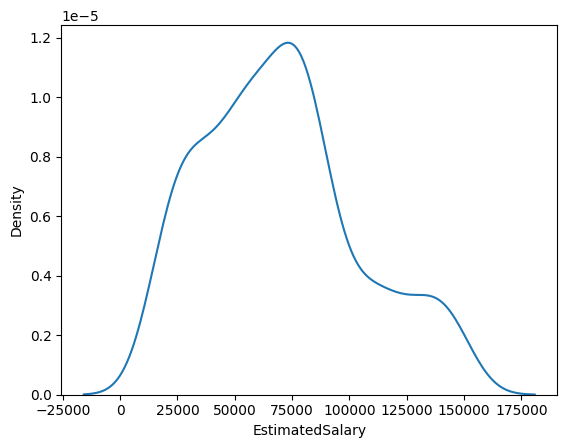

In [36]:
sns.kdeplot(df['EstimatedSalary'])

<Axes: xlabel='Age', ylabel='Density'>

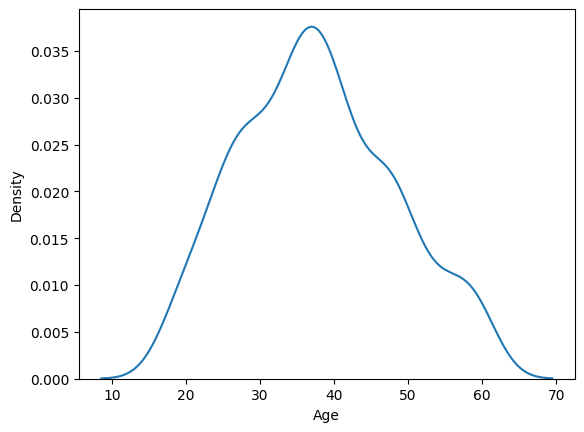

In [37]:
sns.kdeplot(df['Age'])

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

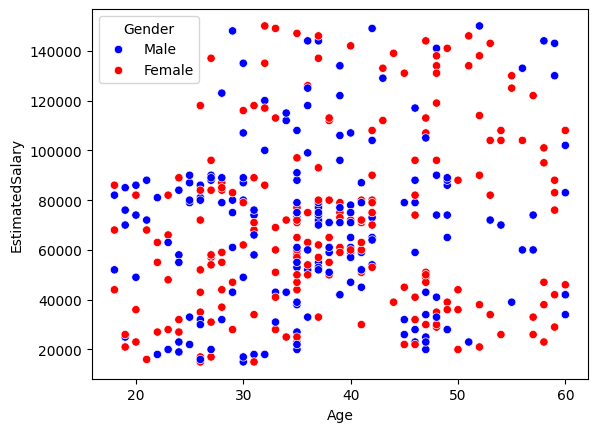

In [38]:
color_dict = {'Male': 'blue', 'Female': 'red'}

sns.scatterplot(
    data=df,
    x='Age',
    y='EstimatedSalary',
    hue='Gender',
    palette=color_dict
)

In [45]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df.drop('Purchased', axis=1),
    df['Purchased'],
    test_size=0.3,
    random_state=0
)

x_train.shape, x_test.shape

((279, 4), (120, 4))

In [55]:
# 1. Encode first
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [56]:
print(df['Gender'].dtype)
print(df['Gender'].head())

int64
0    1
1    0
2    0
3    1
4    1
Name: Gender, dtype: int64


In [59]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df.drop('Purchased', axis=1),
    df['Purchased'],
    test_size=0.3,
    random_state=0
)
x_train.shape , x_test.shape

((279, 4), (120, 4))

In [60]:
# Import the MinMaxScaler from sklearn.preprocessing
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit the scaler on train set . it will learn the parameters
scaler.fit(x_train)

# Transform test data using the already fitted scaler
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [61]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [62]:
np.round(x_train.describe() , 1)

,User ID,Gender,Age,EstimatedSalary
count,279.0,279.0,279.0,279.0
mean,15693037.1,0.5,0.5,0.4
std,71777.1,0.5,0.2,0.2
min,15569641.0,0.0,0.0,0.0
25%,15629428.5,0.0,0.3,0.2
50%,15697424.0,0.0,0.5,0.4
75%,15753488.0,1.0,0.7,0.5
max,15815236.0,1.0,1.0,1.0


In [65]:
np.round(x_train_scaled.describe() , 1)

,User ID,Gender,Age,EstimatedSalary
count,279.0,279.0,279.0,279.0
mean,0.5,0.5,0.5,0.4
std,0.3,0.5,0.2,0.2
min,0.0,0.0,0.0,0.0
25%,0.2,0.0,0.3,0.2
50%,0.5,0.0,0.5,0.4
75%,0.7,1.0,0.7,0.5
max,1.0,1.0,1.0,1.0


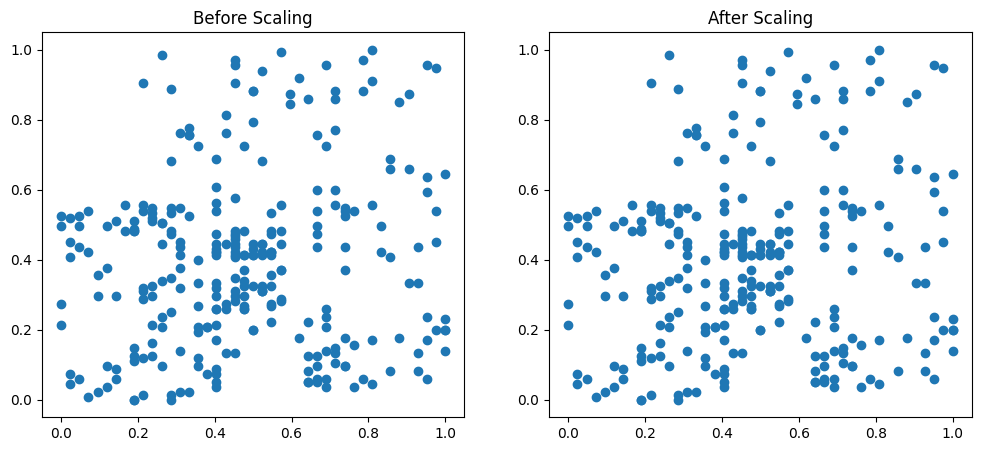

In [67]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before scaling
ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")

# After scaling
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'])
ax2.set_title("After Scaling")

plt.show()

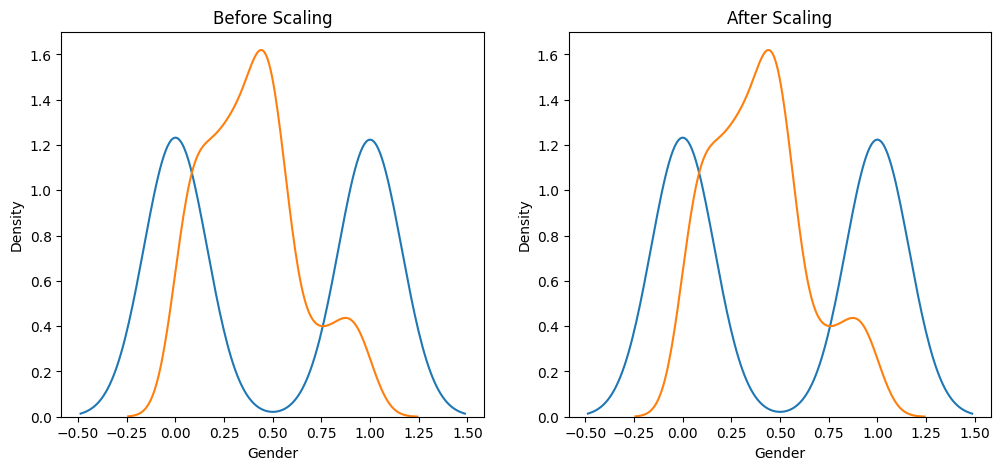

In [68]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(x_train['Gender'] , ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'] , ax=ax1)

# After scaling
ax2.set_title("After Scaling")
sns.kdeplot(x_train_scaled['Gender'] , ax=ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'] , ax=ax2)

plt.show()

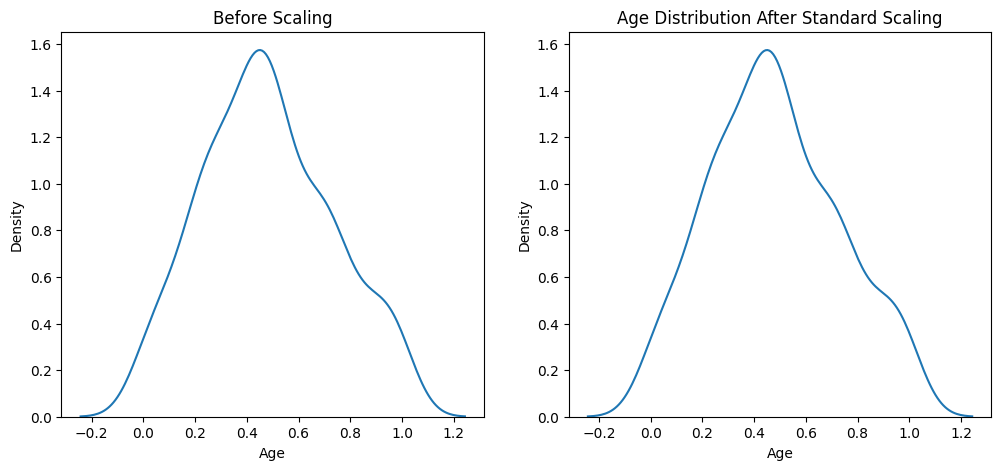

In [69]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(x_train['Age'] , ax=ax1)

# After scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'] , ax=ax2)

plt.show()

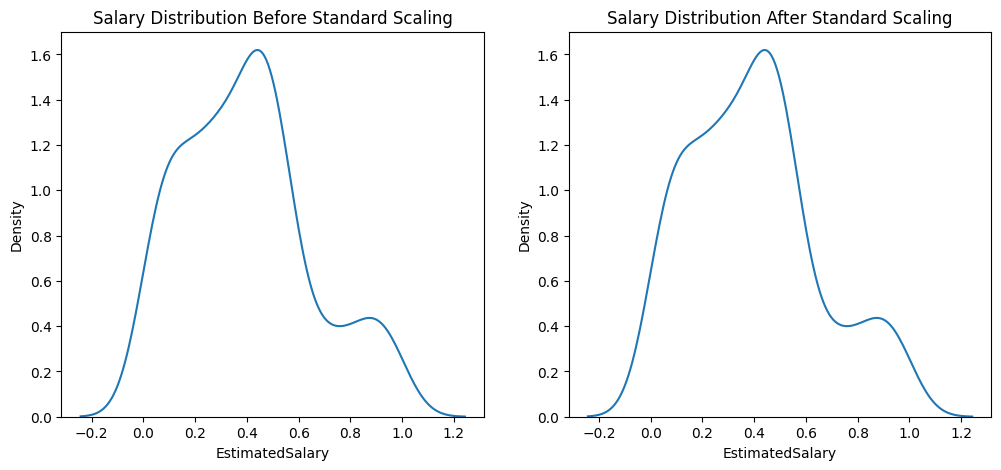

In [70]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before scaling
ax1.set_title('Salary Distribution Before Standard Scaling')
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

# After scaling
ax2.set_title('Salary Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)

plt.show()